# Data loading

In [1]:
from recommender_system.data.load import load_data
from recommender_system.data.transform import transform_reviews

df = load_data('../data/australian_user_reviews.json.gz')
reviews = transform_reviews(df)

reviews = reviews.astype({'recommend': 'int'})
reviews.head()

,user_id,posted,item_id,recommend
0,76561197970982479,"Posted November 5, 2011.",1250,1
1,76561197970982479,"Posted July 15, 2011.",22200,1
2,76561197970982479,"Posted April 21, 2011.",43110,1
3,js41637,"Posted June 24, 2014.",251610,1
4,js41637,"Posted September 8, 2013.",227300,1


# Recommend new games

In [ ]:
from recommender_system.models.collaborative_filtering import get_item_similarity_matrix, get_similar_items

sims, item_to_idx = get_item_similarity_matrix(reviews)

recommendations = get_similar_items('422400', sims, item_to_idx, k=3682)

games = load_data("../data/steam_games.json.gz")
games = games.rename({'id': 'item_id'}, axis=1)
games = games[['item_id', 'app_name']]

recommendations = recommendations.merge(games, on='item_id', how='left')
recommendations.head()


,item_id,scores,app_name
0,261820,0.267261,Estranged: Act I
1,225280,0.267261,Full Mojo Rampage
2,293500,0.142857,Amazing World™
3,293260,0.133631,Card Hunter
4,224260,0.091003,No More Room in Hell


# Get number of reviews per game

In [21]:
import pandas as pd
num_positive = reviews.groupby('item_id')['recommend'].sum()
num_negative = reviews.groupby('item_id')['recommend'].count() - num_positive

reviews_per_game = pd.DataFrame(reviews['item_id'].unique(), columns=['item_id'])
reviews_per_game = reviews_per_game.join(pd.DataFrame([num_positive, num_negative]).T, on='item_id')
reviews_per_game.columns = ['item_id', 'num_positive', 'num_negative']
reviews_per_game['total'] = reviews_per_game['num_positive'] + reviews_per_game['num_negative']
reviews_per_game.head()

,item_id,num_positive,num_negative,total
0,1250,327,7,334
1,22200,6,0,6
2,43110,33,2,35
3,251610,6,0,6
4,227300,107,2,109


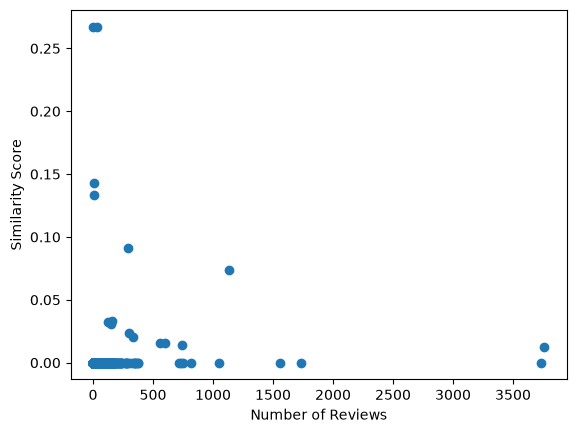

In [26]:
import matplotlib.pyplot as plt
recommendations = recommendations.merge(reviews_per_game, on='item_id', how='left')
recommendations.head()
plt.plot(recommendations['total'], recommendations['scores'], 'o')
plt.xlabel("Number of Reviews")
plt.ylabel("Similarity Score")
plt.show()

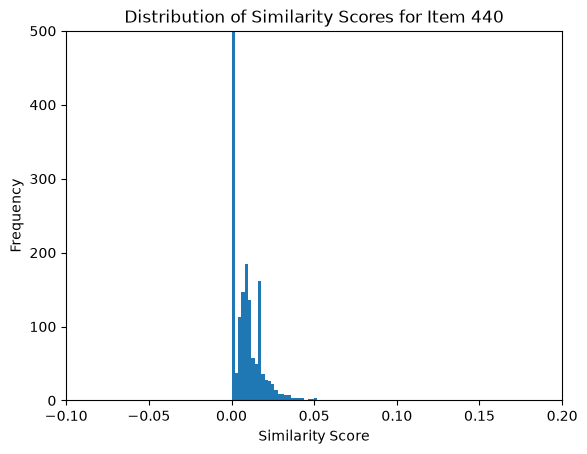

In [ ]:
#Generate histogram of similarity scores for a specific item
import matplotlib.pyplot as plt
plt.hist(sims[item_to_idx["440"]].flatten(), bins=500)
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores for Item 440")
plt.xlim(-0.1, 0.2)
plt.ylim(0, 500)
plt.show()